## Composition findings

EGFR-mutant tumors (n=5 samples) show increased proportions of immunosuppressive myeloid cells (TAMs, MDSCs) and NK cells relative to wild-type (n=4 samples), while wild-type tumors are enriched for fibroblasts and monocytes. The bulk T cell compartment is largely unchanged between groups.


No cell type reaches p<0.05 after two-sided Mann-Whitney U testing at the patient level. All comparisons are underpowered given the small sample size (n=5 vs n=4); results should be treated as hypothesis-generating. The directional enrichment of TAMs and MDSCs in EGFR-mutant tumors is consistent with the central observation of Zhou et al. (2022) that EGFR-mutant LUAD harbors an immunosuppressive microenvironment driven by myeloid polarization.

# 04 — EGFR Status and TME Composition

Quantifies cell type composition differences between EGFR-mutant and EGFR-wildtype tumors using patient-level proportions. Statistical testing uses Mann-Whitney U on per-sample fractions to respect patient independence.

In [1]:
import pandas as pd
from IPython.display import Image, display

comp_per_sample = pd.read_csv('../results/tables/composition_per_sample.csv', index_col=0)
comp_by_egfr   = pd.read_csv('../results/tables/composition_by_egfr.csv', index_col=0)
stats_df       = pd.read_csv('../results/tables/composition_stats.csv')

print(f"Samples: {len(comp_per_sample)}")
print(f"Cell types: {len(comp_by_egfr)}")

Samples: 9
Cell types: 14


## Per-sample composition

Each row is one patient; values are % of that patient's cells assigned to each cell type.

In [2]:
comp_per_sample.round(2)

,B,Endothelial,Fibroblast,MDSC,Malignant_epi,Mast,Monocyte,NK,Plasma,TAM,T_CD4,T_CD8,Treg,pDC
sample_id,,,,,,,,,,,,,,
CYD,9.73,0.10,0.08,0.24,0.97,0.26,0.08,5.83,3.36,4.40,32.72,41.51,0.12,0.58
CYZ,1.85,2.15,0.33,0.24,17.48,0.82,4.05,9.14,1.36,17.59,19.58,23.49,0.08,1.85
GBG,2.91,0.77,20.63,0.00,33.80,0.09,1.68,4.09,1.04,13.27,8.13,11.00,0.05,2.54
LJQ,18.73,0.45,1.35,0.48,4.71,0.97,0.07,1.80,9.90,5.75,10.11,43.89,0.03,1.77
LYB.1,0.32,1.75,3.67,0.10,47.38,0.15,0.52,3.22,0.85,13.54,12.09,13.61,0.10,2.70
LYB.2,1.61,1.03,0.93,0.37,24.45,0.33,2.28,8.21,1.10,22.21,16.67,17.09,0.72,3.01
TGS,9.41,1.12,3.33,0.26,13.37,0.65,2.16,2.24,12.09,8.92,14.49,29.93,0.16,1.87
XMS,1.77,0.75,0.82,0.27,21.68,0.07,11.34,1.68,3.94,7.26,23.03,27.17,0.13,0.09
ZYQ,2.58,1.15,1.38,0.31,4.16,0.05,1.43,9.48,1.05,4.75,28.72,43.61,0.05,1.28


## Cell type composition by EGFR status

Pooled proportions across all cells in each EGFR group. Used for the stacked bar visualization only — not for statistics.

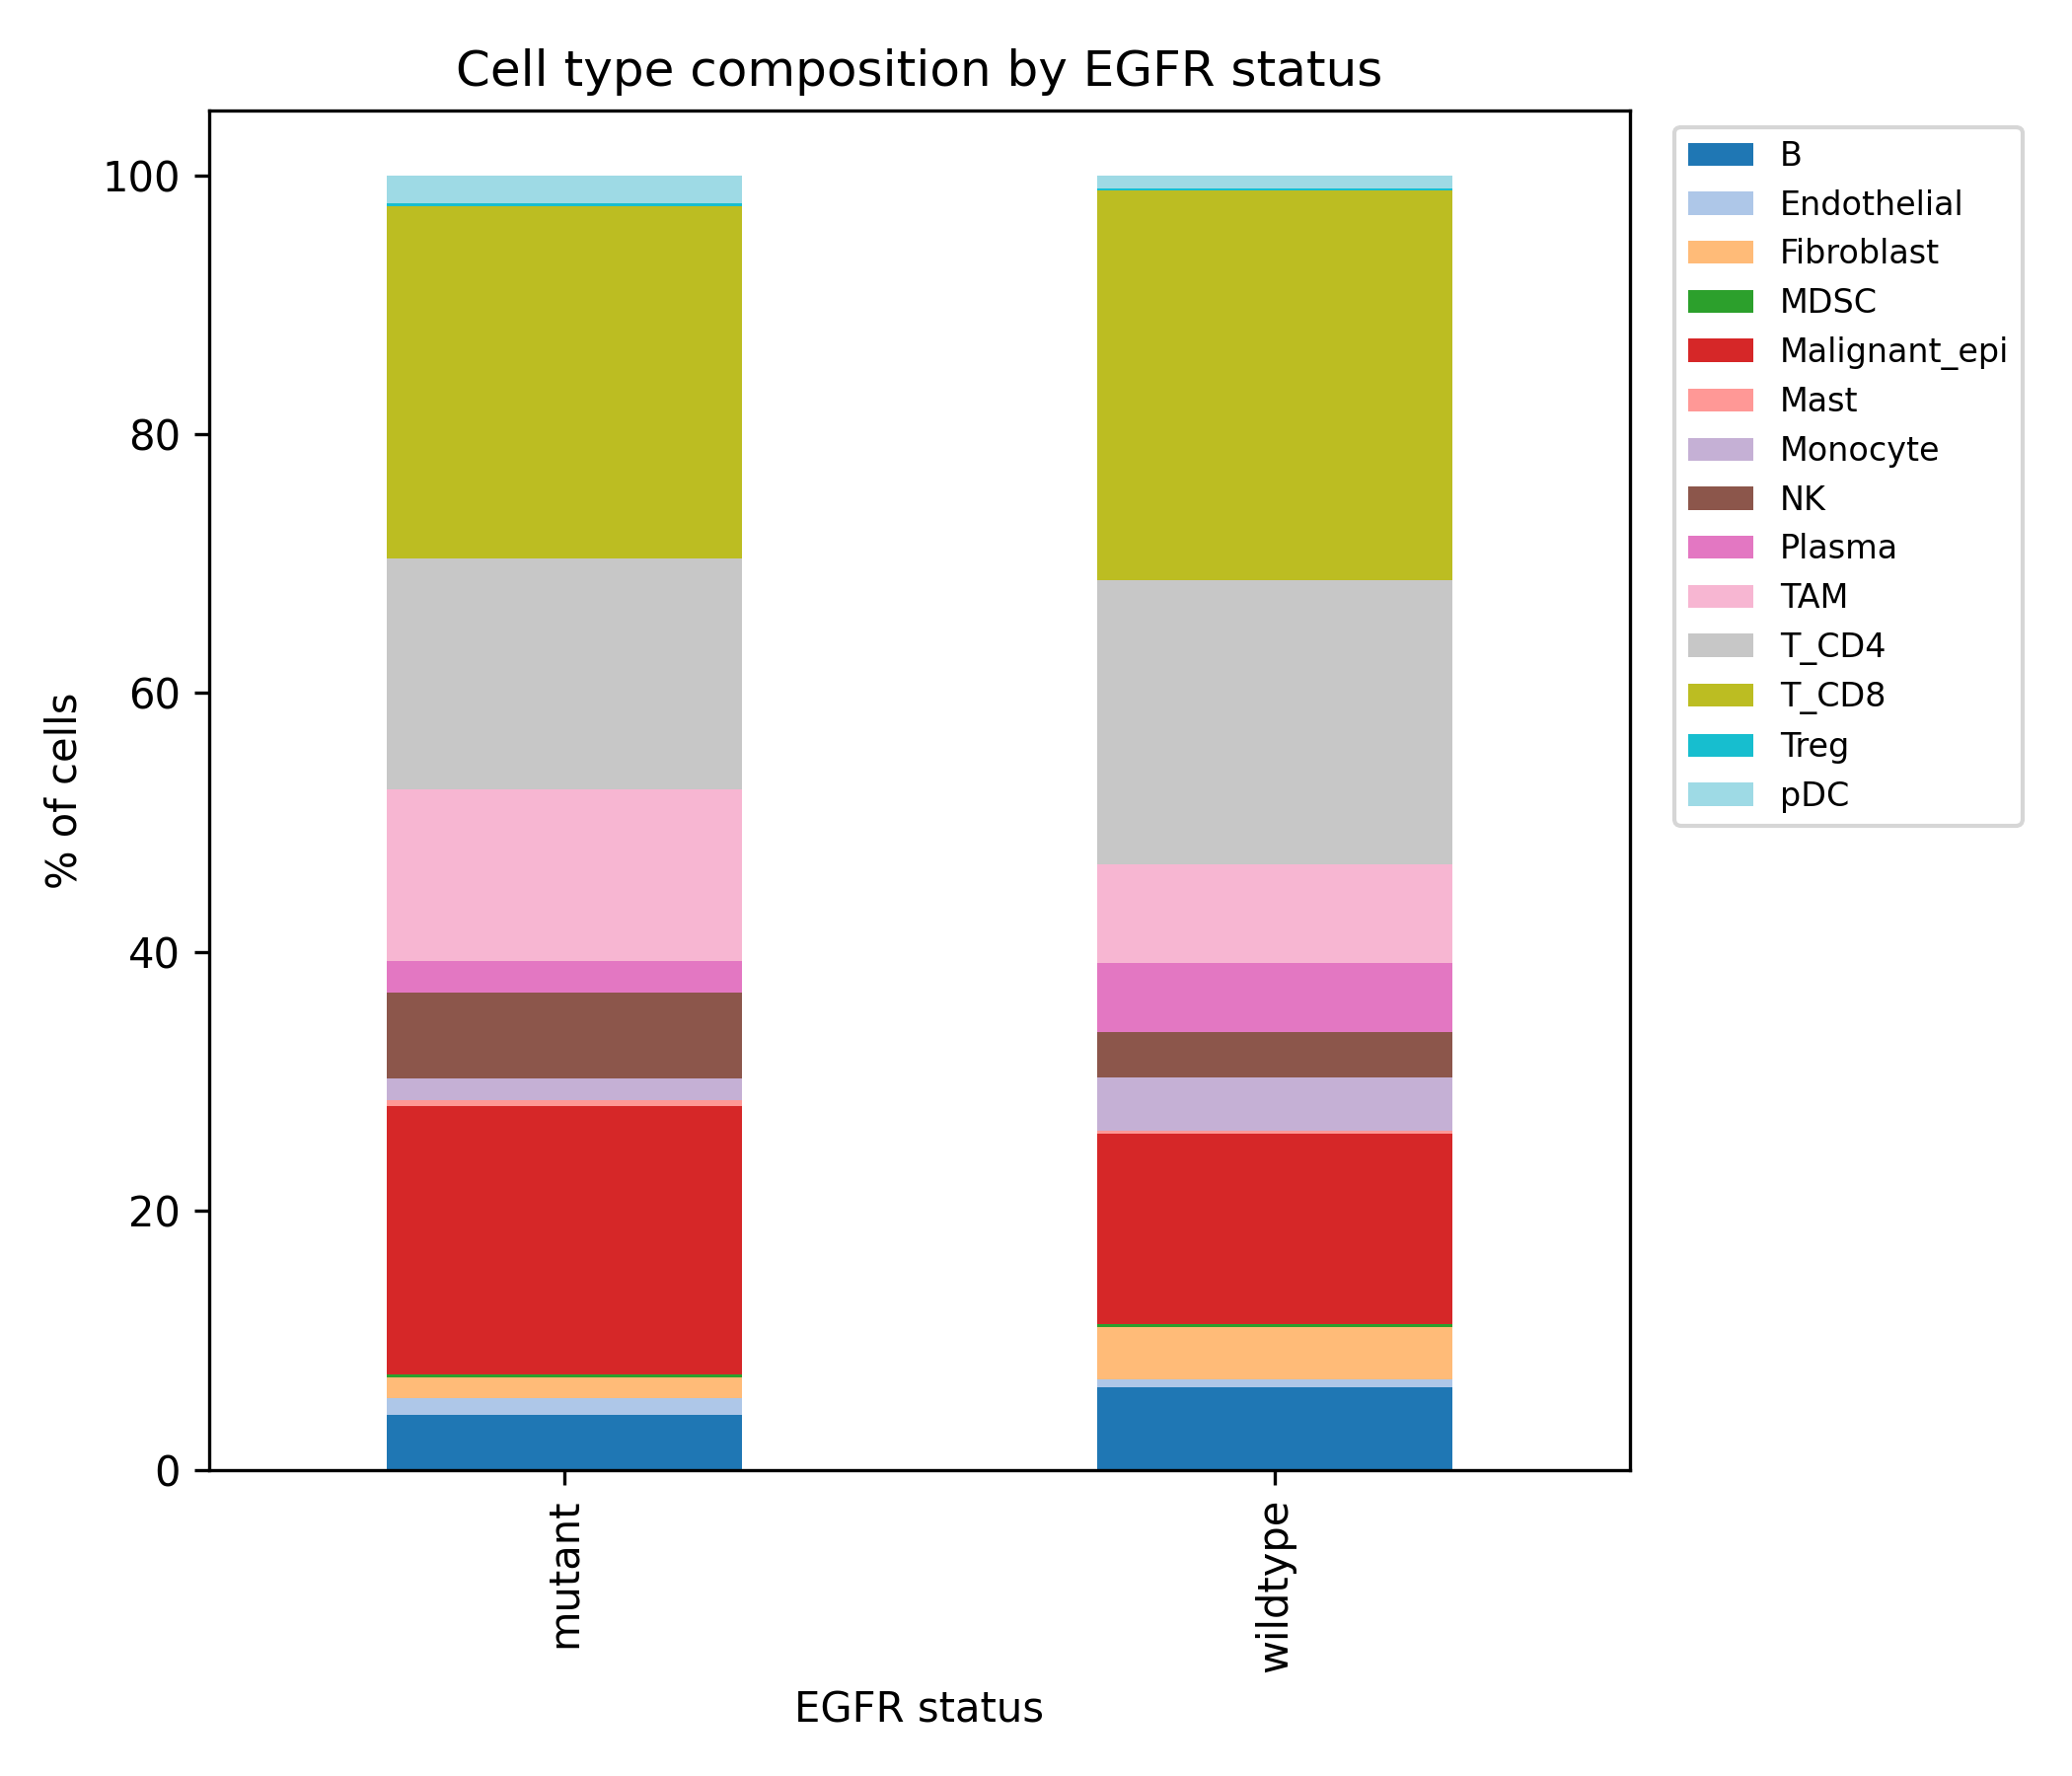

,mutant,wildtype
cell_type,,
B,4.22,6.37
Endothelial,1.34,0.64
Fibroblast,1.56,4.01
MDSC,0.29,0.22
Malignant_epi,20.71,14.71
Mast,0.43,0.28
Monocyte,1.74,4.09
NK,6.60,3.49
Plasma,2.44,5.36


In [3]:
display(Image('../results/figures/composition_stacked.png'))
comp_by_egfr.round(2)

## MDSC enrichment in EGFR-mutant tumors

Patient-level MDSC fractions split by EGFR status. Each dot is one patient.

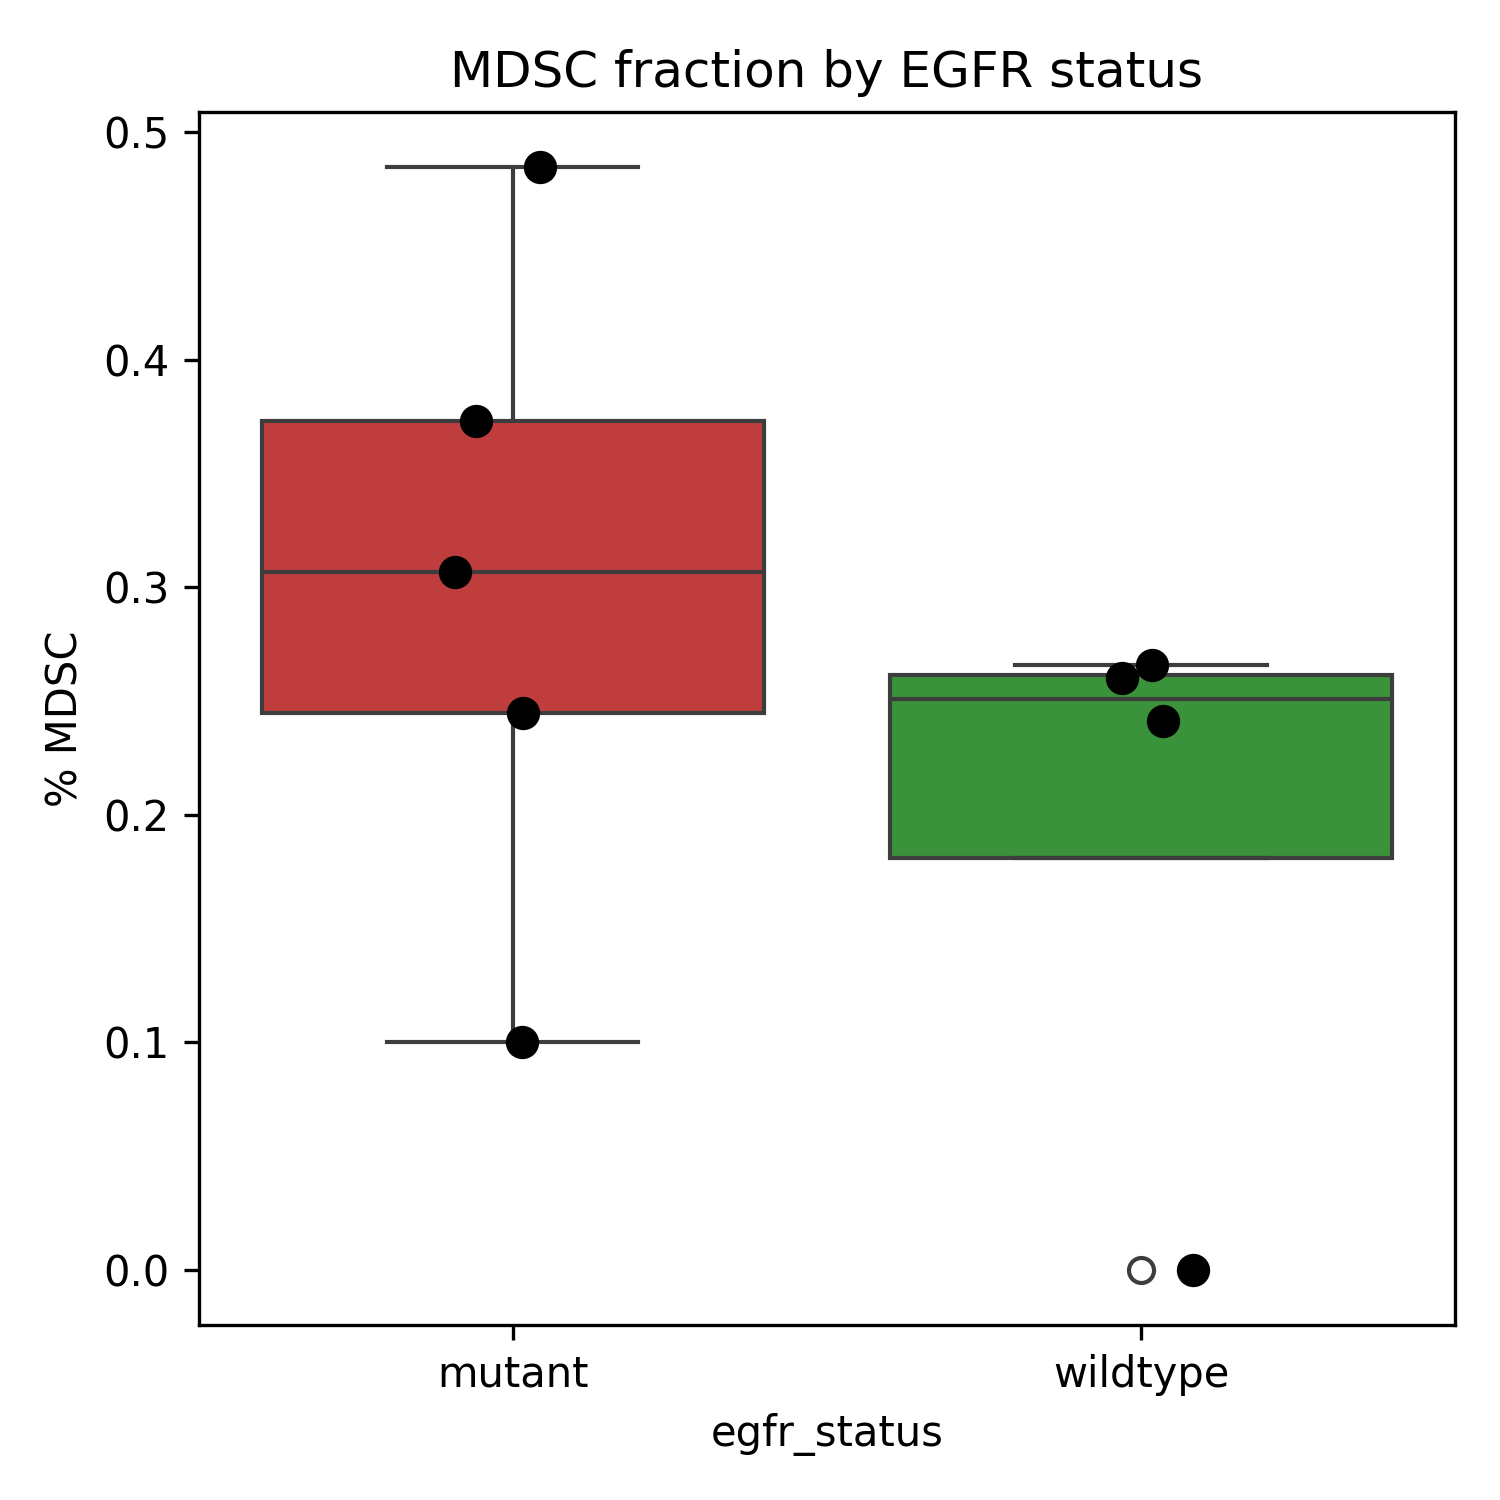

In [4]:
display(Image('../results/figures/mdsc_by_egfr.png'))

## Statistical summary

Mann-Whitney U (two-sided) on patient-level proportions. `mut_median` / `wt_median` are per-patient medians. `log2_FC` uses a +1 pseudocount: `(mut_median + 1) / (wt_median + 1)`. Sorted by p-value ascending.

In [5]:
stats_df.round(4)

,cell_type,mut_median,wt_median,log2_FC,pvalue
0,Endothelial,1.1497,0.7626,1.2196,0.1905
1,NK,8.2051,3.1629,2.2113,0.2857
2,MDSC,0.3066,0.2507,1.0447,0.2857
3,B,1.8488,6.1613,0.3978,0.4127
4,pDC,1.8488,1.2279,1.2787,0.4127
5,TAM,13.5365,8.0919,1.5988,0.4127
6,Plasma,1.0956,3.6502,0.4506,0.4127
7,Mast,0.3263,0.1762,1.1277,0.5556
8,Treg,0.0816,0.1268,0.9599,0.5556
9,Monocyte,1.4308,1.9199,0.8325,0.7302
